In [ ]:
import sys
import numpy as np
from scipy.stats import binom
import pandas as pd
import sklearn as sk
import scipy as sp
import tensorflow as tf
import platform
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, auc
import psutil
import re
import seaborn as sns

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
batch_size = 64
lr = 0.01

base_project_folder_path = "./drive/MyDrive/AI Systems/computer_vision"
# base_project_folder_path = "."
final_model_path = f"{base_project_folder_path}/final_models"

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

In [ ]:
def preprocess_chunk(chunk):
    # Select feature columns (start with 'pixel_')
    X = chunk.filter(regex=r'^pixel_').values
    X = X.reshape((-1, 224, 224, 3))
    # Select target columns (exclude those with 'image' in the name)
    Y = chunk.loc[:, ~((chunk.columns.str.contains('image')) | (chunk.columns.str.contains('pixel_')))].values
    return X, Y


In [ ]:
def load_model_l(model_name):

    print(model_name)
    if os.path.exists(f"./{model_name}.h5"):
        print(f"Loading existing model from .h5 format: {model_name}.h5")
        model = tf.keras.models.load_model(f"./{model_name}.h5")
    elif os.path.exists(f"./{model_name}.keras"):
        print(f"Loading existing model from .keras format: {model_name}.keras")
        model = tf.keras.models.load_model(f"./{model_name}.keras")
    else:
        print(f"No existing model found. Starting with a new model.")
        return None

    for layer in model.layers:
        if "mobilenetv2" in layer.name.lower():  # Ensure you're targeting the correct layers
            layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def manual_auc(fpr, tpr):
    auc_value = np.trapz(tpr, fpr)
    return auc_value

def roc_auc(fpr, tpr):

  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, marker='o', linestyle='-', label="ROC Curve")
  plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Classifier")

  plt.xlabel("False Positive Rate -> Rejection Rate")
  plt.ylabel("True Positive Rate -> Non-Rejected Accuracy")
  plt.title("ROC Curve for Rejector-Based Classifier")
  plt.legend()
  plt.grid(True)

  auc_score = manual_auc(fpr, tpr)
  print(f"ACU score = {auc_score}")
  plt.show()
  return auc_score


def roc_auc_no_line(fpr, tpr):

    plt.figure(figsize=(8, 6))

  # Plot the ROC curve as a scatter plot (no lines between points)
    plt.scatter(fpr, tpr, marker='o', label="ROC Curve")

    # Plot the random classifier (diagonal line)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Classifier")

    # Labels and title
    plt.xlabel("False Positive Rate -> Rejection Rate")
    plt.ylabel("True Positive Rate -> Non-Rejected Accuracy")
    plt.title("ROC Curve for Rejector-Based Classifier")

    # Add legend and grid
    plt.legend()
    plt.grid(True)

    # Compute the AUC score
    auc_score = manual_auc(fpr, tpr)
    print(f"AUC score = {auc_score}")

    # Show the plot
    plt.show()



def metrics_by_epochs(fpr, tpr, epochs_list):

  plt.figure(figsize=(10, 5))
  plt.plot(epochs_list, tpr, marker='o', linestyle='-', label="Non-Rejected Accuracy")
  plt.plot(epochs_list, fpr, marker='s', linestyle='--', label="Rejection rate")
  plt.xlabel("Epochs")
  plt.ylabel("Metric Value")
  plt.title("Test Metrics per Epoch")
  plt.legend()
  plt.grid(True)
  plt.show()




def metric_by_epochs(metric, epochs_list):

  plt.figure(figsize=(10, 5))
  plt.plot(epochs_list, metric, marker='o', linestyle='-', label="Non-Rejected Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Metric Value")
  plt.title("Test Metrics per Epoch")
  plt.legend()
  plt.grid(True)
  plt.show()

  max_index = max(range(len(metric)), key=lambda i: metric[i])
  best_epoch = epochs_list[max_index]
  best_value = metric[max_index]
  return best_epoch, best_value



In [ ]:
test_df_path = f"{base_project_folder_path}/data/ordered_test_df.csv"
# validation_df_path = f"./{base_project_folder_path}/data/ordered_validation_df.csv"
test_df = pd.read_csv(test_df_path)
test_X, test_Y = preprocess_chunk(test_df)

In [ ]:
len(test_df)

In [ ]:
Y_labels = test_df.loc[:, ~((test_df.columns.str.contains('image')) | (test_df.columns.str.contains('pixel_')))].columns.tolist()

Y_labels

Base not rejector model (trained with best hyperparams found):

In [ ]:
plain_eval = {}
test_acc_list = []
test_loss_list = []
rejection_rate_list = []
epochs_list = []
auc_list = []
roc_curves = {}

num_classes = test_Y.shape[1]

for epoch in range(1, 41):

    model_name = f"{base_project_folder_path}/final_models/plain_model_straight_eps" + f"_{epoch}epoch"

    model = load_model_l(model_name)

    if not model:
        print(f"Skipping epoch {epoch} due to missing model.")
        continue

    print(f"test after Epoch {epoch}")

    # Get test loss and accuracy
    test_loss, test_acc = model.evaluate(test_X,test_Y, batch_size=batch_size)

    # Get model predictions (probabilities)
    y_pred_prob = model.predict(test_X)  # Shape: (num_samples, num_classes)

    # Compute AUC for each class (One-vs-Rest)
    auc_scores_per_class = []
    fpr_dict, tpr_dict = {}, {}

    for class_idx in range(num_classes):
        y_true_binary = test_Y[:, class_idx]  # Take this class as positive (1) and others as negative (0)
        y_pred_binary = y_pred_prob[:, class_idx]  # Take probabilities for this class

        # Compute ROC curve and AUC for this class
        fpr, tpr, _ = roc_curve(y_true_binary, y_pred_binary)
        auc_score = auc(fpr, tpr)

        auc_scores_per_class.append(auc_score)
        fpr_dict[class_idx] = fpr
        tpr_dict[class_idx] = tpr

    # Store macro-average AUC (mean of all class AUCs)
    macro_auc = np.mean(auc_scores_per_class)

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)
    auc_list.append(macro_auc)
    epochs_list.append(epoch)
    roc_curves[epoch] = (fpr_dict, tpr_dict)  # Save all ROC curves for this epoch

    print(f"  test Loss: {test_loss:.4f}, test Accuracy: {test_acc:.4f}, Macro AUC: {macro_auc:.4f}")
    print("----------------------------------")

plain_eval['test_acc'] = test_acc_list
plain_eval['test_loss'] = test_loss_list
plain_eval['auc'] = auc_list
plain_eval['epochs_list'] = epochs_list


print(plain_eval)

./final_models/plain_model_straight_eps_1epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_1epoch.h5


2025-03-09 20:53:50.379497: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-03-09 20:53:50.379516: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-03-09 20:53:50.379529: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-03-09 20:53:50.379544: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-09 20:53:50.379555: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


test after Epoch 1


2025-03-09 20:53:52.968133: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.6018 - loss: 1.6410
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step
  test Loss: 1.7785, test Accuracy: 0.5820, Macro AUC: 0.7166
----------------------------------
./final_models/plain_model_straight_eps_2epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_2epoch.h5


...

test after Epoch 36
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 635ms/step - accuracy: 0.6550 - loss: 2.6533
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step
  test Loss: 2.9259, test Accuracy: 0.6250, Macro AUC: 0.7785
----------------------------------
./final_models/plain_model_straight_eps_37epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_37epoch.h5


test after Epoch 37
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 562ms/step - accuracy: 0.6339 - loss: 4.0441
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 337ms/step
  test Loss: 4.4360, test Accuracy: 0.6052, Macro AUC: 0.7627
----------------------------------
./final_models/plain_model_straight_eps_38epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_38epoch.h5


test after Epoch 38
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 548ms/step - accuracy: 0.6575 - loss: 3.4937
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 274ms/step
  test Loss: 3.9511, test Accuracy: 0.6263, Macro AUC: 0.7526
----------------------------------
./final_models/plain_model_straight_eps_39epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_39epoch.h5


test after Epoch 39
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 568ms/step - accuracy: 0.6333 - loss: 2.6883
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step
  test Loss: 2.8969, test Accuracy: 0.6045, Macro AUC: 0.7769
----------------------------------
./final_models/plain_model_straight_eps_40epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_40epoch.h5


test after Epoch 40
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 614ms/step - accuracy: 0.6234 - loss: 3.6277
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 344ms/step
  test Loss: 3.9741, test Accuracy: 0.5999, Macro AUC: 0.7630
----------------------------------
{'test_acc': [0.5820105671882629, 0.5992063283920288, 0.6071428656578064, 0.5965608358383179, 0.3928571343421936, 0.6058201193809509, 0.6164020895957947, 0.6190476417541504, 0.5985449552536011, 0.5978835821151733, 0.6197090148925781, 0.6111111044883728, 0.5932539701461792, 0.5998677015304565, 0.6111111044883728, 0.6124338507652283, 0.6078042387962341, 0.6044973731040955, 0.6322751045227051, 0.4980158805847168, 0.6071428656578064, 0.6170634627342224, 0.6084656119346619, 0.5813491940498352, 0.5965608358383179, 0.5972222089767456, 0.6044973731040955, 0.6137565970420837, 0.6084656119346619, 0.6243386268615723, 0.6170634627342224, 0.5853174328804016, 0.6210317611694336, 0.625, 0.6051587462425232, 0.6263227462768555, 0.6044973731040955, 0.5998677015304565], 'te

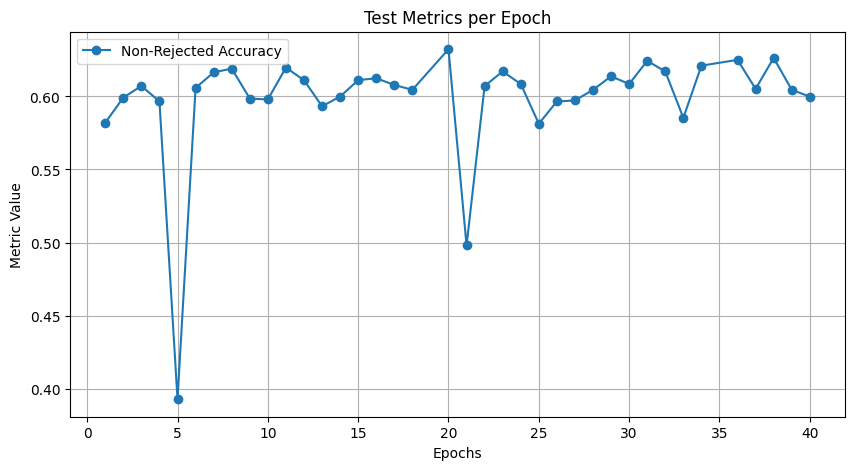

In [ ]:
best_epoch, best_value = metric_by_epochs(plain_eval['test_acc'], plain_eval["epochs_list"])

In [ ]:
plain_eval['test_acc']

[0.5820105671882629,
 0.5992063283920288,
 0.6071428656578064,
 0.5965608358383179,
 0.3928571343421936,
 0.6058201193809509,
 0.6164020895957947,
 0.6190476417541504,
 0.5985449552536011,
 0.5978835821151733,
 0.6197090148925781,
 0.6111111044883728,
 0.5932539701461792,
 0.5998677015304565,
 0.6111111044883728,
 0.6124338507652283,
 0.6078042387962341,
 0.6044973731040955,
 0.6322751045227051,
 0.4980158805847168,
 0.6071428656578064,
 0.6170634627342224,
 0.6084656119346619,
 0.5813491940498352,
 0.5965608358383179,
 0.5972222089767456,
 0.6044973731040955,
 0.6137565970420837,
 0.6084656119346619,
 0.6243386268615723,
 0.6170634627342224,
 0.5853174328804016,
 0.6210317611694336,
 0.625,
 0.6051587462425232,
 0.6263227462768555,
 0.6044973731040955,
 0.5998677015304565]

In [ ]:
plain_eval.keys()

dict_keys(['test_acc', 'test_loss', 'auc', 'epochs_list'])

In [ ]:
index_max = np.argmax(plain_eval['test_acc'])
print(plain_eval['epochs_list'][index_max])
plain_eval['test_acc'][index_max]

20


0.6322751045227051

In [ ]:
plain_eval['auc'][best_epoch]

0.7657760535199996

In [ ]:
index_max = np.argmax(plain_eval['auc'])
print(index_max)
plain_eval['auc'][index_max]

25


0.7790312919891458

even though epoch 29 has better auc, the metric we have to compare to the academec paraers are the acc there thoughg we wil chose to continue with the best acc, epoch 24

In [ ]:
best_model_name = f"{base_project_folder_path}/final_models/plain_model_straight_eps" + f"_24epoch"
best_base_model = load_model_l(best_model_name)
print()
test_loss, test_acc = best_base_model.evaluate(test_X, test_Y, batch_size=batch_size)
print(f"\n  test Loss: {test_loss:.4f}, test Accuracy: {test_acc:.4f}")

./final_models/final_models/plain_model_straight_eps_24epoch
No existing model found. Starting with a new model.
./final_models/final_models/plain_model_straight_eps_24epoch


AttributeError: 'NoneType' object has no attribute 'evaluate'

In [ ]:
best_model_name = f"{base_project_folder_path}/final_models/plain_model_straight_eps" + f"_{best_epoch}epoch"
best_base_model = load_model_l(best_model_name)

test_loss, test_acc = best_base_model.evaluate(test_X, test_Y, batch_size=batch_size)
print(f"\n  test Loss: {test_loss:.4f}, test Accuracy: {test_acc:.4f}")

./final_models/plain_model_straight_eps_20epoch
Loading existing model from .h5 format: ./final_models/plain_model_straight_eps_20epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 673ms/step - accuracy: 0.6631 - loss: 2.7453

  test Loss: 3.0639, test Accuracy: 0.6323


In [ ]:
print(best_epoch)

20


48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step


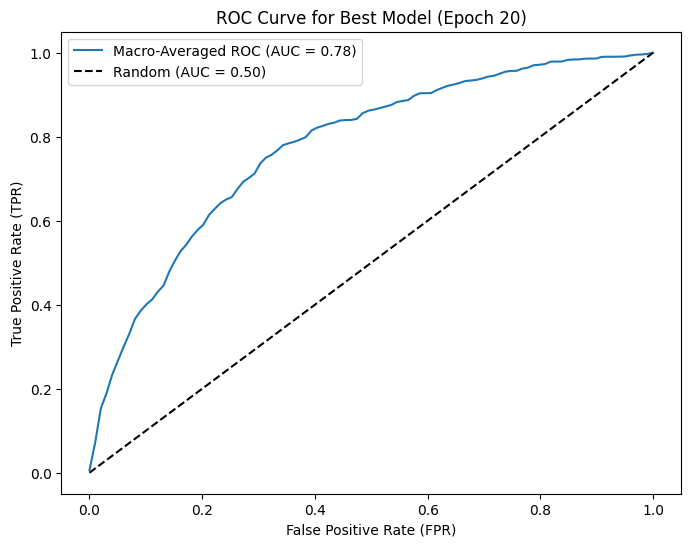

In [ ]:
# Get model probabilities
y_pred_prob = best_base_model.predict(test_X)

# Compute One-vs-Rest (OvR) ROC curve
num_classes = test_Y.shape[1] - 1
all_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(test_Y[:, i], y_pred_prob[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)

mean_tpr /= num_classes  # Average TPRs across classes
macro_auc = auc(all_fpr, mean_tpr)



# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-Averaged ROC (AUC = {macro_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Best Model (Epoch 20)")
plt.legend()
plt.show()

In [ ]:
test_preds = best_base_model.predict(test_X)
test_preds_classes = np.argmax(test_preds, axis=1)
test_true_classes = np.argmax(test_Y, axis=1)

report = classification_report(test_true_classes, test_preds_classes)
print(report)

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step
              precision    recall  f1-score   support

           0       0.44      0.36      0.40       171
           1       0.71      0.90      0.79       909
           2       0.29      0.23      0.25        93
           3       0.00      0.00      0.00        43
           4       0.41      0.26      0.32       217
           5       0.00      0.00      0.00        44
           6       0.18      0.09      0.12        35

    accuracy                           0.63      1512
   macro avg       0.29      0.26      0.27      1512
weighted avg       0.56      0.63      0.59      1512



/opt/anaconda3/envs/coda_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/coda_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/coda_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step


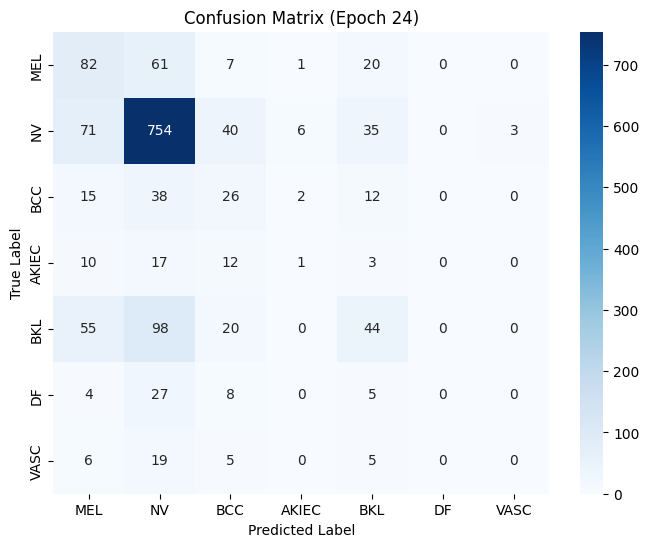

In [ ]:
y_pred = model.predict(test_X)
y_pred_labels = y_pred.argmax(axis=1)  # Convert probabilities to class predictions
y_true_labels = test_Y.argmax(axis=1)  # Convert one-hot to class indices

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=Y_labels, yticklabels=Y_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Epoch 20)")
plt.show()


thresholds:

In [ ]:
# validation_df_path = f"./{base_project_folder_path}/data/ordered_validation_df.csv"
test_df_path = f"{base_project_folder_path}/ordered_test_df.csv"
test_df = pd.read_csv(test_df_path)
test_df["RJ"] = 0
test_X, test_Y = preprocess_chunk(test_df)

In [ ]:
eval_dict = {}
best_models_per_threshold = {}
print(thresholds)
for cur_threshold in thresholds:

    test_acc_list = []
    test_loss_list = []
    rejection_rate_list = []
    epochs_list = []
    auc_list = []

    model_name_base = f"{base_project_folder_path}/final_models/model_rj_with_threshold_{cur_threshold}"
    eval_dict[cur_threshold] = {}

    for epoch in range(1, 25):

        model_name = model_name_base + f"_{epoch}epoch"
        print('----------------------')
        print(f"threshold = {cur_threshold}")

        model = load_model_l(model_name)

        if not model:
            print(f"Skipping epoch {epoch} due to missing model.")
            continue

        test_preds = model.predict(test_X, batch_size=batch_size)
        test_preds_classes = np.argmax(test_preds, axis=1)
        true_classes = np.argmax(test_Y, axis=1)
        reject_class = test_Y.shape[1] - 1

        reject_mask = (test_preds_classes == reject_class)
        rejection_rate = np.mean(reject_mask)

        non_reject_mask = ~reject_mask
        if np.any(non_reject_mask):
            test_acc = np.mean(test_preds_classes[non_reject_mask] == true_classes[non_reject_mask])
        else:
            test_acc = 0

        # Store metrics
        test_acc_list.append(test_acc)
        rejection_rate_list.append(rejection_rate)
        epochs_list.append(epoch)

    eval_dict[cur_threshold]['epochs_list'] = epochs_list
    eval_dict[cur_threshold]['test_acc'] = test_acc_list
    eval_dict[cur_threshold]['rejection_rate'] = rejection_rate_list

    # break



[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
----------------------
threshold = 0.05
./final_models/model_rj_with_threshold_0.05_1epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.05_1epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 550ms/step
----------------------
threshold = 0.05
./final_models/model_rj_with_threshold_0.05_2epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.05_2epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 730ms/step
----------------------
threshold = 0.05
./final_models/model_rj_with_threshold_0.05_3epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.05_3epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 836ms/step
----------------------
threshold = 0.05
./final_models/model_rj_with_threshold_0.05_4epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.05_4epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 715ms/step
----------------------
threshold = 0.05
./final_models/model_rj_with_threshold_0.05_5epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.05_5epoch.h5


...

24/24 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step 
----------------------
threshold = 0.5
./final_models/model_rj_with_threshold_0.5_21epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.5_21epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step 
----------------------
threshold = 0.5
./final_models/model_rj_with_threshold_0.5_22epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.5_22epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step 
----------------------
threshold = 0.5
./final_models/model_rj_with_threshold_0.5_23epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.5_23epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step 
----------------------
threshold = 0.5
./final_models/model_rj_with_threshold_0.5_24epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.5_24epoch.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step 


In [ ]:
# auc_thresholds = {}
# best_rejectors_indexes_by_thresholds = {}

# for cur_threshold in thresholds:

#     cur_metrics = eval_dict[cur_threshold]

#     fpr = cur_metrics['rejection_rate']
#     tpr = cur_metrics['test_acc']

#     print(f"For threshold {cur_threshold}:")
#     metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
#     auc = roc_auc(fpr, tpr)
#     auc_thresholds[cur_threshold] = auc

#     distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
#     best_model_idx = np.argmin(distances)
#     best_fpr = fpr[best_model_idx]
#     best_tpr = tpr[best_model_idx]
#     best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

#     best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

#     print(f"Best Model Index: {best_model_idx}")
#     print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

#     print('----------------------------------------------')

#     break

In [ ]:
auc_thresholds = {}
best_rejectors_indexes_by_thresholds = {}

For threshold 0.05:


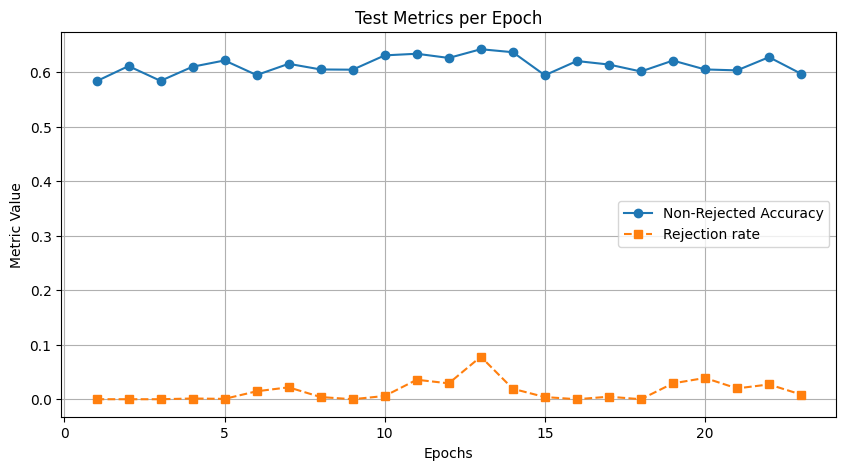

AUC score = 0.005355778266590616


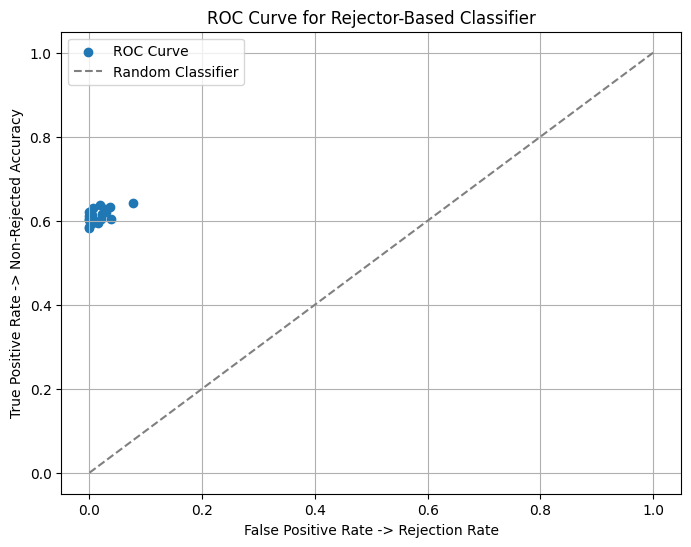

[0.41666667 0.38888889 0.41600529 0.39006847 0.37855782 0.40563018
 0.38533799 0.39510625 0.39550265 0.36930945 0.36799231 0.3751087
 0.36637126 0.36395818 0.4057299  0.37962963 0.38607427 0.39880952
 0.3798629  0.39696725 0.39725694 0.37352127 0.40302701]
Best Model Index: 13
Best FPR: 0.0192, Best TPR: 0.6365, Best Rejection Rate: 0.0192
----------------------------------------------


In [ ]:
cur_threshold = 0.05
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
print(f"{distances}")
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


In [ ]:
print(eval_dict[0.05])
print(eval_dict[0.1])

{'epochs_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], 'test_acc': [0.5833333333333334, 0.6111111111111112, 0.583994708994709, 0.6099337748344371, 0.6214427531436135, 0.5946308724832214, 0.6152805949966194, 0.6049136786188579, 0.6044973544973545, 0.6307385229540918, 0.6337448559670782, 0.6260217983651226, 0.6420373027259685, 0.6365475387727579, 0.5942895086321381, 0.6203703703703703, 0.6139534883720931, 0.6011904761904762, 0.6212534059945504, 0.6049552649690296, 0.6032388663967612, 0.6274643099932019, 0.5970647098065377], 'rejection_rate': [0.0, 0.0, 0.0, 0.0013227513227513227, 0.0006613756613756613, 0.01455026455026455, 0.021825396825396824, 0.003968253968253968, 0.0, 0.005952380952380952, 0.03571428571428571, 0.0291005291005291, 0.07804232804232804, 0.01917989417989418, 0.003968253968253968, 0.0, 0.004629629629629629, 0.0, 0.0291005291005291, 0.03902116402116402, 0.01984126984126984, 0.027116402116402115, 0.008597883597883597]}
{'epochs_l

For threshold 0.1:


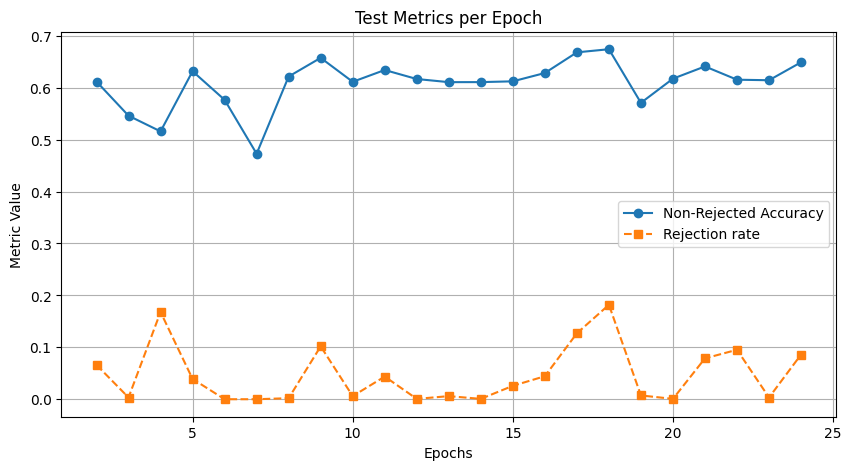

AUC score = 0.014051952119136013


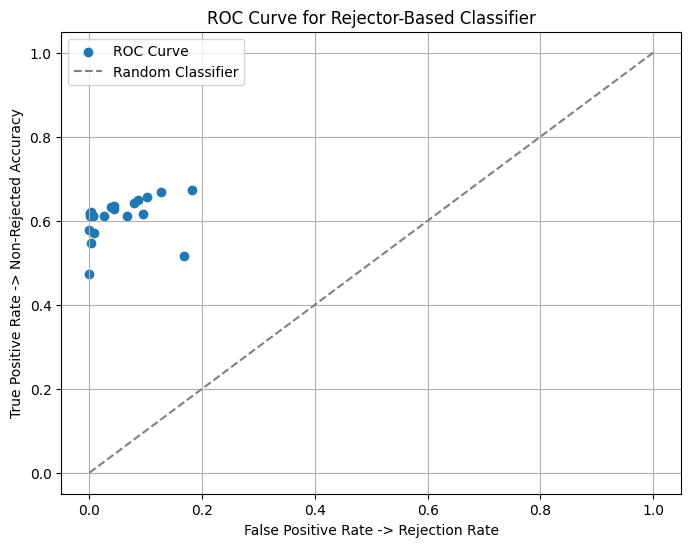

Best Model Index: 15
Best FPR: 0.1270, Best TPR: 0.6682, Best Rejection Rate: 0.1270
----------------------------------------------


In [ ]:
cur_threshold = 0.1
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.15:


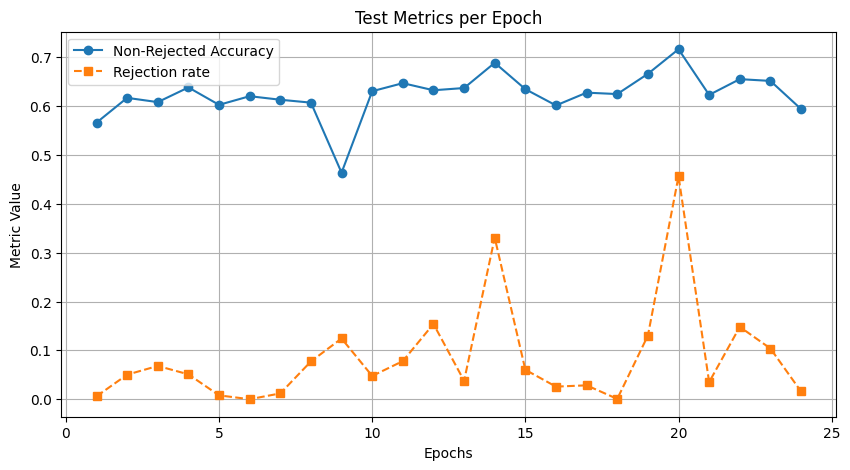

AUC score = 0.013218144274555164


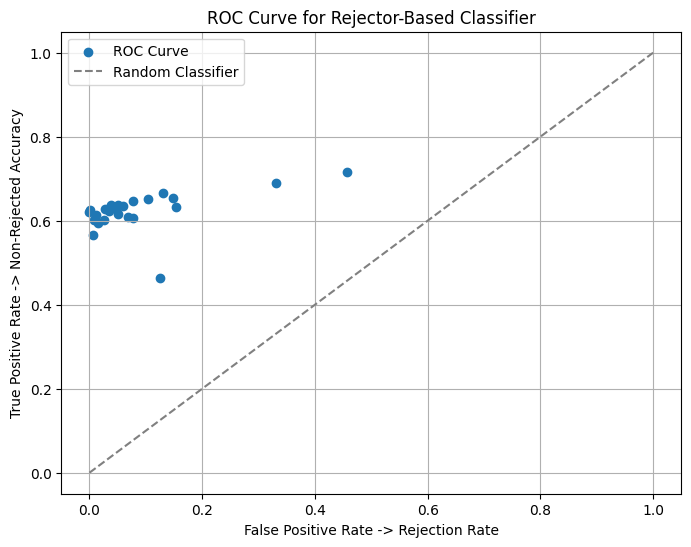

Best Model Index: 18
Best FPR: 0.1303, Best TPR: 0.6662, Best Rejection Rate: 0.1303
----------------------------------------------


In [ ]:
cur_threshold = 0.15
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.2:


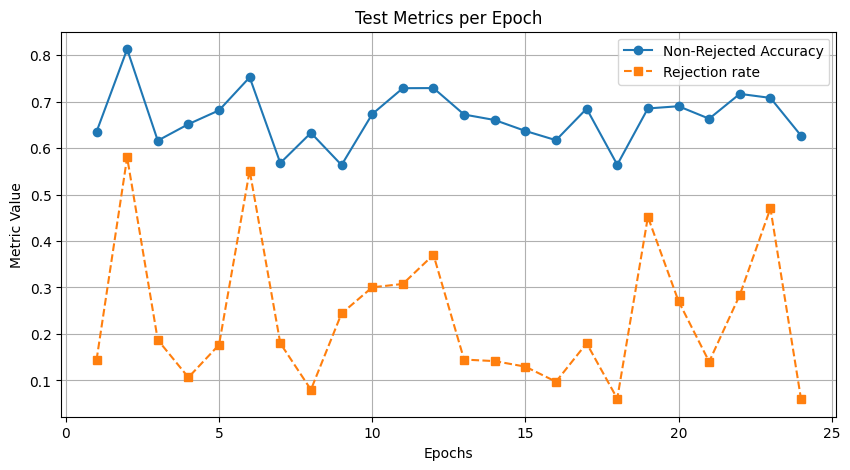

AUC score = -0.04145649625477965


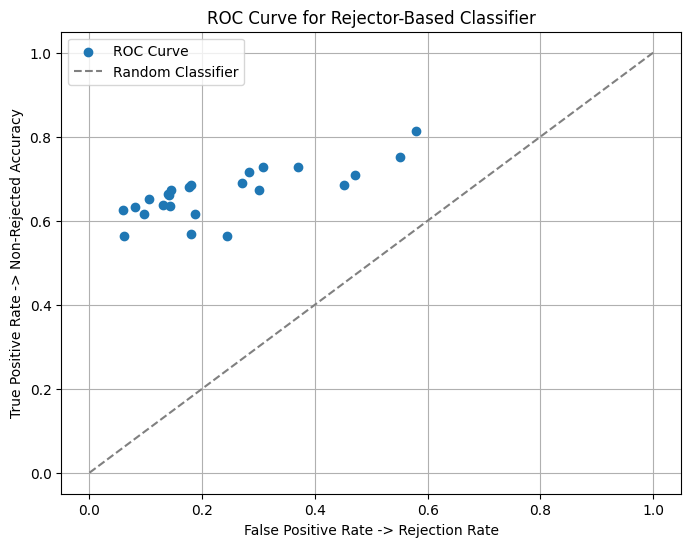

Best Model Index: 12
Best FPR: 0.1448, Best TPR: 0.6721, Best Rejection Rate: 0.1448
----------------------------------------------


In [ ]:
cur_threshold = 0.2
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.25:


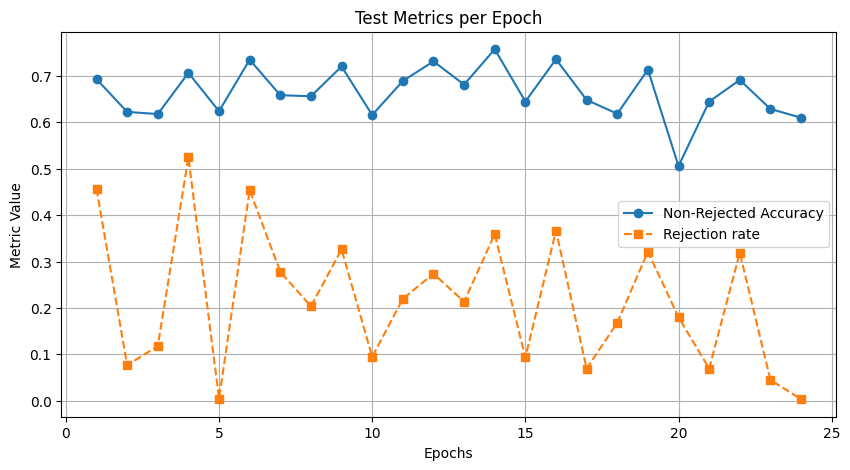

AUC score = -0.28411923851311754


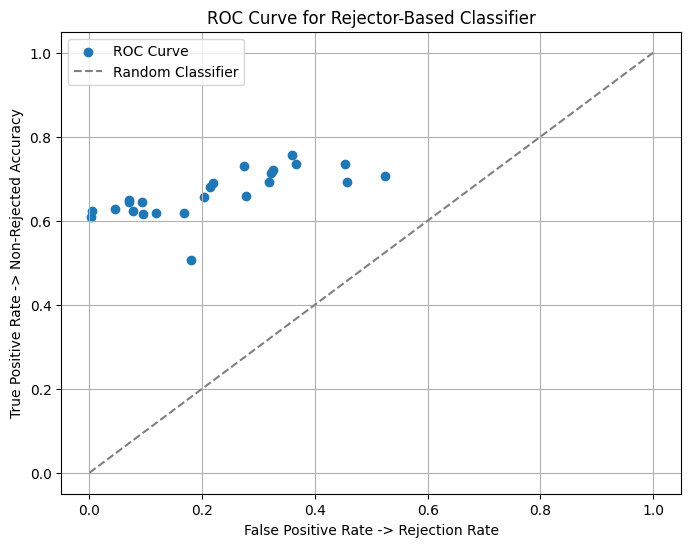

Best Model Index: 16
Best FPR: 0.0694, Best TPR: 0.6482, Best Rejection Rate: 0.0694
----------------------------------------------


In [ ]:
cur_threshold = 0.25
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.3:


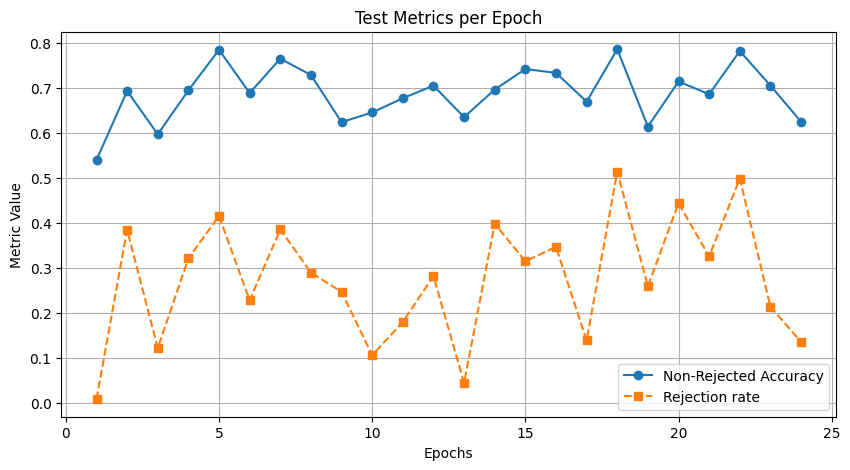

AUC score = 0.058770512384849316


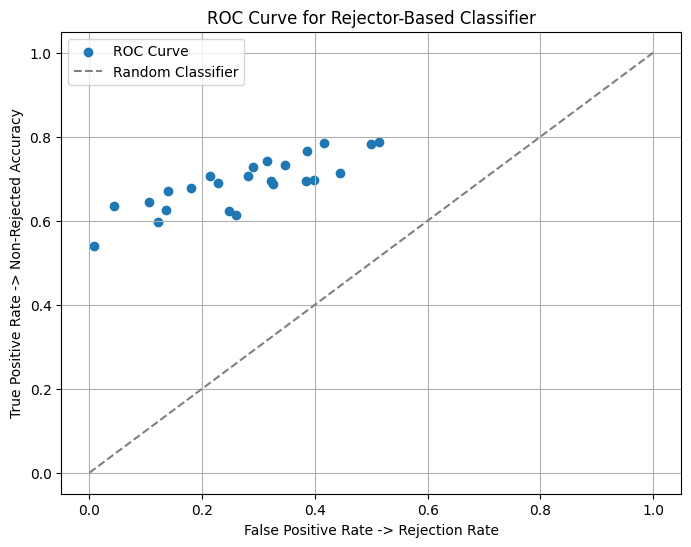

Best Model Index: 16
Best FPR: 0.1389, Best TPR: 0.6697, Best Rejection Rate: 0.1389
----------------------------------------------


In [ ]:
cur_threshold = 0.3
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.35:


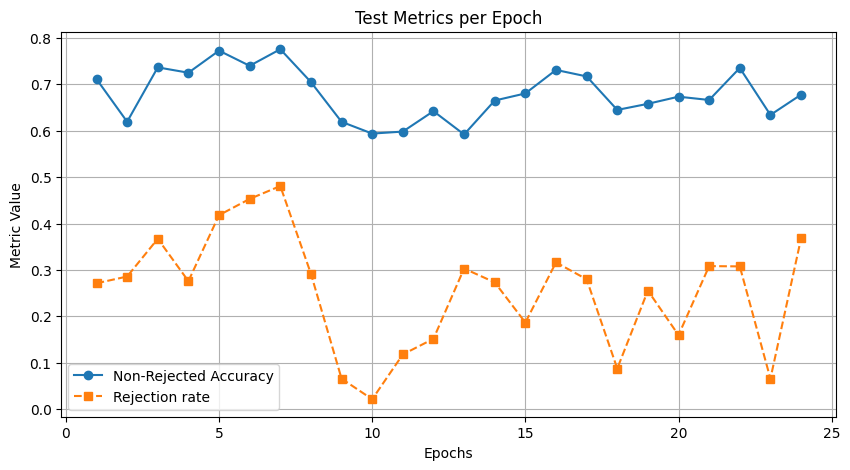

AUC score = 0.04186158894306066


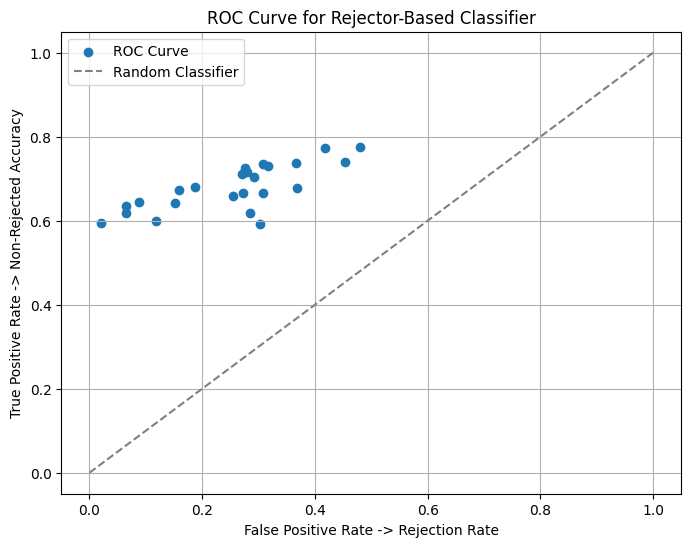

Best Model Index: 19
Best FPR: 0.1594, Best TPR: 0.6735, Best Rejection Rate: 0.1594
----------------------------------------------


In [ ]:
cur_threshold = 0.35
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.4:


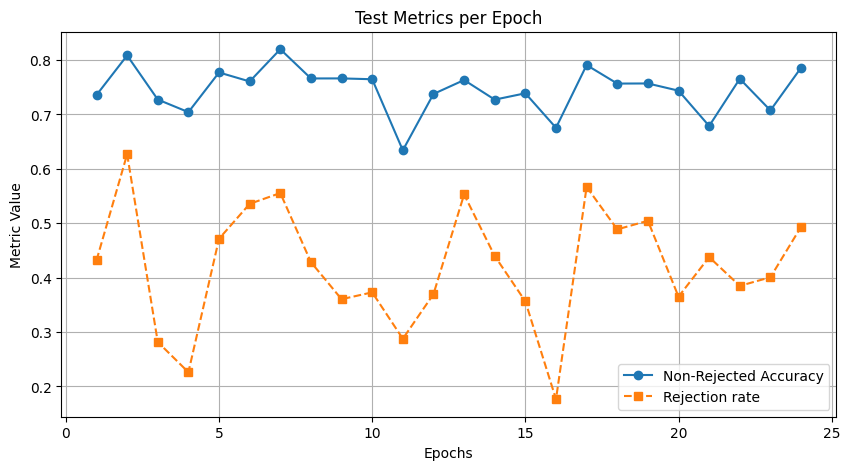

AUC score = 0.038049775848524


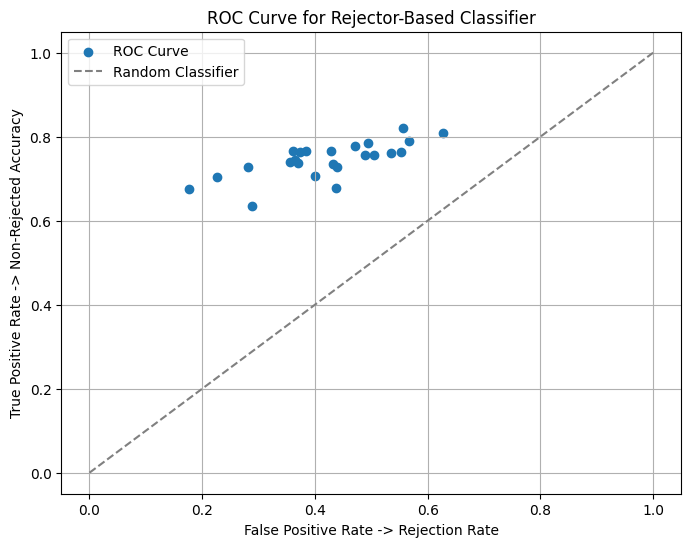

Best Model Index: 15
Best FPR: 0.1766, Best TPR: 0.6755, Best Rejection Rate: 0.1766
----------------------------------------------


In [ ]:
cur_threshold = 0.4
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.45:


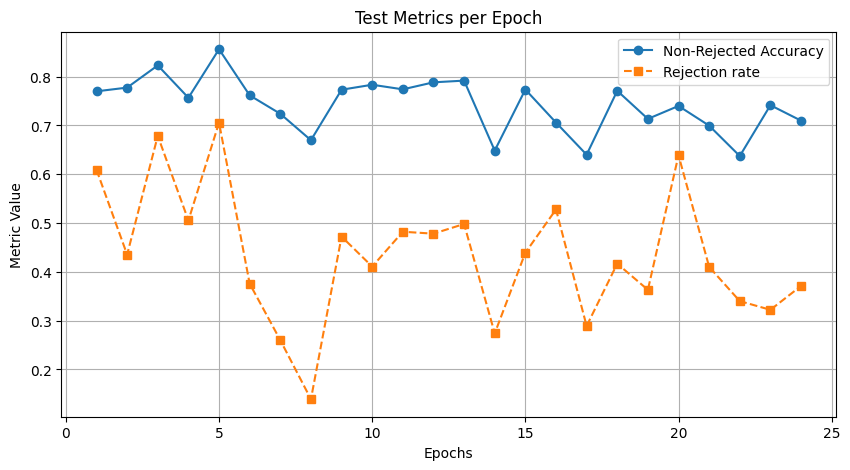

AUC score = -0.16818324040187177


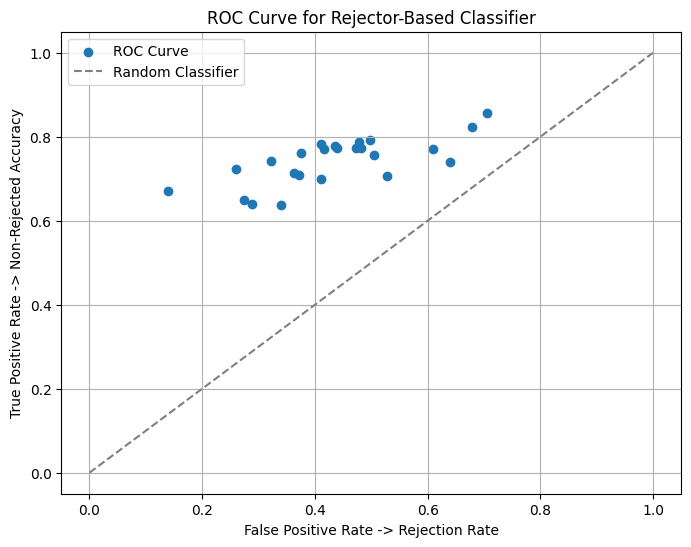

Best Model Index: 7
Best FPR: 0.1389, Best TPR: 0.6697, Best Rejection Rate: 0.1389
----------------------------------------------


In [ ]:
cur_threshold = 0.45
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


For threshold 0.5:


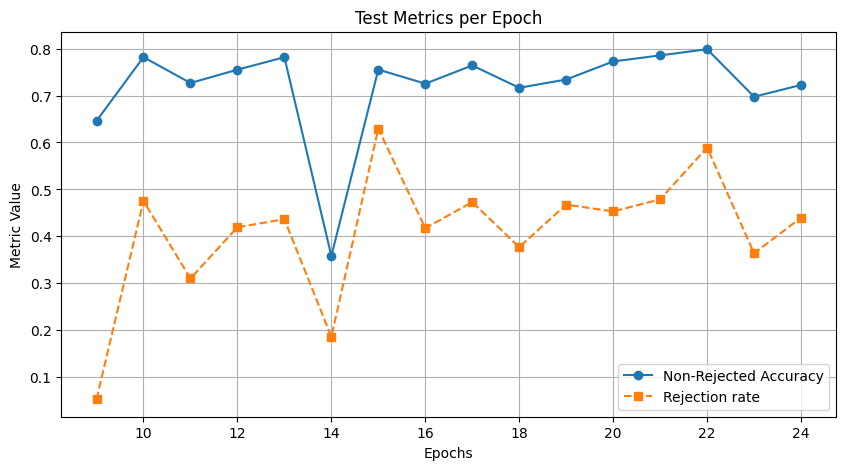

AUC score = 0.236118327825246


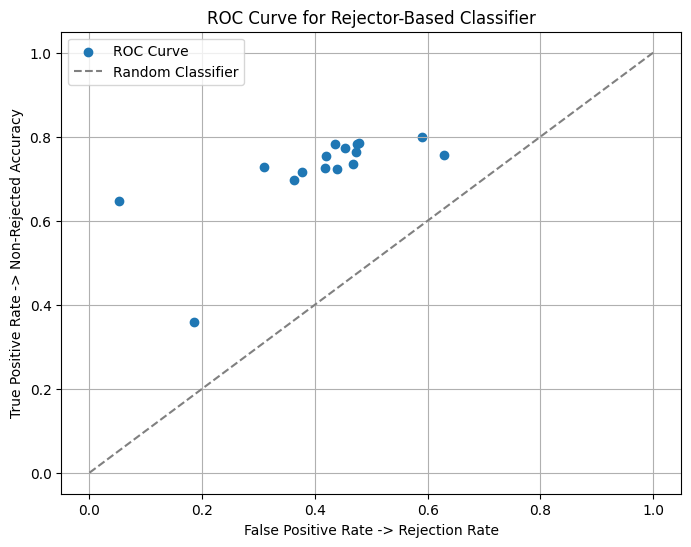

Best Model Index: 0
Best FPR: 0.0529, Best TPR: 0.6459, Best Rejection Rate: 0.0529
----------------------------------------------


In [ ]:
cur_threshold = 0.5
cur_metrics = eval_dict[cur_threshold]

fpr = cur_metrics['rejection_rate']
tpr = cur_metrics['test_acc']

print(f"For threshold {cur_threshold}:")
metrics_by_epochs(fpr, tpr, cur_metrics["epochs_list"])
auc = roc_auc_no_line(fpr, tpr)
auc_thresholds[cur_threshold] = auc

distances = np.sqrt(np.array(fpr)**2 + (1 - np.array(tpr))**2)
best_model_idx = np.argmin(distances)
best_fpr = fpr[best_model_idx]
best_tpr = tpr[best_model_idx]
best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

best_rejectors_indexes_by_thresholds[cur_threshold] = {"model_index": best_model_idx}

print(f"Best Model Index: {best_model_idx}")
print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

print('----------------------------------------------')


In [ ]:
best_rejectors_indexes_by_thresholds

{0.05: {'model_index': 13},
 0.1: {'model_index': 15},
 0.15: {'model_index': 18},
 0.2: {'model_index': 12},
 0.25: {'model_index': 16},
 0.3: {'model_index': 16},
 0.35: {'model_index': 19},
 0.4: {'model_index': 15},
 0.45: {'model_index': 7},
 0.5: {'model_index': 0}}

In [ ]:
for item in best_rejectors_indexes_by_thresholds:
  epoch_ver = eval_dict[item]["epochs_list"][best_rejectors_indexes_by_thresholds[item]['model_index']]
  model_name_base = f"{base_project_folder_path}/final_models/model_rj_with_threshold_{item}"
  model_name = model_name_base + f"_{epoch_ver}epoch"
  rejector_model = load_model_l(model_name)
  best_rejectors_indexes_by_thresholds[item]['model_name'] = model_name
  best_rejectors_indexes_by_thresholds[item]['rejector_model'] = rejector_model



./final_models/model_rj_with_threshold_0.05_14epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.05_14epoch.h5


./final_models/model_rj_with_threshold_0.1_17epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.1_17epoch.h5


./final_models/model_rj_with_threshold_0.15_19epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.15_19epoch.h5


./final_models/model_rj_with_threshold_0.2_13epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.2_13epoch.h5


./final_models/model_rj_with_threshold_0.25_17epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.25_17epoch.h5


./final_models/model_rj_with_threshold_0.3_17epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.3_17epoch.h5


./final_models/model_rj_with_threshold_0.35_20epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.35_20epoch.h5


./final_models/model_rj_with_threshold_0.4_16epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.4_16epoch.h5


./final_models/model_rj_with_threshold_0.45_8epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.45_8epoch.h5


./final_models/model_rj_with_threshold_0.5_9epoch
Loading existing model from .h5 format: ./final_models/model_rj_with_threshold_0.5_9epoch.h5


In [ ]:
original_preds = best_base_model.predict(test_X).argmax(axis=1)

true_labels = test_Y.argmax(axis=1)

total_samples = len(original_preds)
num_correct = np.sum(original_preds == true_labels)
num_wrong = total_samples - num_correct
accuracy_original = num_correct / total_samples
error_rate_original = num_wrong / total_samples

print("Original Model Performance:")
print(f"Total Predictions: {total_samples}")
print(f"Correct Predictions: {num_correct}")
print(f"Incorrect Predictions: {num_wrong}")
print(f"Accuracy: {accuracy_original:.4f}")
print(f"Error Rate: {error_rate_original:.4f}")
print("---------------------")

48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step
Original Model Performance:
Total Predictions: 1512
Correct Predictions: 956
Incorrect Predictions: 556
Accuracy: 0.6323
Error Rate: 0.3677
---------------------


In [ ]:
#  p = 0.5  version of binom!!!!
for item in best_rejectors_indexes_by_thresholds:

  print('-----------------------')
  print(f"Eval for rejector model for threshold {item}:")

  rejector_model = best_rejectors_indexes_by_thresholds[item]['rejector_model']
  rejector_preds = rejector_model.predict(test_X).argmax(axis=1)

  reject_class = test_Y.shape[1] - 1
  rejected_indices = np.where(rejector_preds == reject_class)[0]
  num_rejected = len(rejected_indices)

  true_labels = test_Y.argmax(axis=1)

  if num_rejected == 0:
      print("No cases were rejected. No evaluation needed.")
  else:
      misclassified_by_original = np.sum(original_preds[rejected_indices] != true_labels[rejected_indices])

      total_samples = len(original_preds)
      error_rate_original = np.mean(original_preds != true_labels)
      p_value = 1 - binom.cdf(misclassified_by_original - 1, num_rejected, 0.5)
      print(f"Total rejected cases: {num_rejected}")
      print(f"Misclassified cases (original model) among rejected: {misclassified_by_original}")
      print(f"Baseline model error rate: {error_rate_original:.4f}")
      print(f"P-value from Binomial test: {p_value:.4f}")

      if p_value < 0.05:
          print("Rejector significantly improves classification (p < 0.05).")
      else:
          print("Rejector does NOT significantly improve classification.")


  print('---------------------')
  # break

-----------------------
Eval for rejector model for threshold 0.05:
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 624ms/step
Total rejected cases: 29
Misclassified cases (original model) among rejected: 19
Baseline model error rate: 0.3677
P-value from Binomial test: 0.0680
Rejector does NOT significantly improve classification.
---------------------
-----------------------
Eval for rejector model for threshold 0.1:
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step
Total rejected cases: 192
Misclassified cases (original model) among rejected: 125
Baseline model error rate: 0.3677
P-value from Binomial test: 0.0000
Rejector significantly improves classification (p < 0.05).
---------------------
-----------------------
Eval for rejector model for threshold 0.15:
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 566ms/step
Total rejected cases: 197
Misclassified cases (original model) among rejected: 135
Baseline model error rate: 0.3677
P-value from Binomial test: 0.0000
Rejector significantly improves classification (p < 0.05).

In [ ]:
#  p = 0.5  version of binom!!!!
for item in best_rejectors_indexes_by_thresholds:

  print('-----------------------')
  print(f"Eval for rejector model for threshold {item}:")

  rejector_model = best_rejectors_indexes_by_thresholds[item]['rejector_model']
  rejector_preds = rejector_model.predict(test_X).argmax(axis=1)

  reject_class = test_Y.shape[1] - 1
  rejected_indices = np.where(rejector_preds == reject_class)[0]
  num_rejected = len(rejected_indices)

  true_labels = test_Y.argmax(axis=1)

  if num_rejected == 0:
      print("No cases were rejected. No evaluation needed.")
  else:
      misclassified_by_original = np.sum(original_preds[rejected_indices] != true_labels[rejected_indices])

      total_samples = len(original_preds)
      error_rate_original = np.mean(original_preds != true_labels)

      print(misclassified_by_original, num_rejected)
      p_value = 1 - binom.cdf(misclassified_by_original - 1, num_rejected, 0.5)
      print(f"Total rejected cases: {num_rejected}")
      print(f"Misclassified cases (original model) among rejected: {misclassified_by_original}")
      print(f"Baseline model error rate: {error_rate_original:.4f}")
      print(f"P-value from Binomial test: {p_value:.4f}")

      if p_value < 0.05:
          print("Rejector significantly improves classification (p < 0.05).")
      else:
          print("Rejector does NOT significantly improve classification.")


  print('---------------------')
  if item == 0.15:
    break

-----------------------
Eval for rejector model for threshold 0.05:
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step
19 29
Total rejected cases: 29
Misclassified cases (original model) among rejected: 19
Baseline model error rate: 0.3677
P-value from Binomial test: 0.0680
Rejector does NOT significantly improve classification.
---------------------
-----------------------
Eval for rejector model for threshold 0.1:
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 310ms/step
125 192
Total rejected cases: 192
Misclassified cases (original model) among rejected: 125
Baseline model error rate: 0.3677
P-value from Binomial test: 0.0000
Rejector significantly improves classification (p < 0.05).
---------------------
-----------------------
Eval for rejector model for threshold 0.15:
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 487ms/step
135 197
Total rejected cases: 197
Misclassified cases (original model) among rejected: 135
Baseline model error rate: 0.3677
P-value from Binomial test: 0.0000
Rejector significantly improves class

-----------------------
Eval for rejector model for threshold 0.05:
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step
Total rejected cases: 29
Accuracy for non-rejected cases: 0.6365
Rejection rate: 0.0192
---------------------
-----------------------
Eval for rejector model for threshold 0.1:
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step
Total rejected cases: 192
Accuracy for non-rejected cases: 0.6682
Rejection rate: 0.1270
---------------------
-----------------------
Eval for rejector model for threshold 0.15:
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step
Total rejected cases: 197
Accuracy for non-rejected cases: 0.6662
Rejection rate: 0.1303
---------------------
-----------------------
Eval for rejector model for threshold 0.2:
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 466ms/step
Total rejected cases: 219
Accuracy for non-rejected cases: 0.6721
Rejection rate: 0.1448
---------------------
-----------------------
Eval for rejector model for threshold 0.25:
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step
Total reje

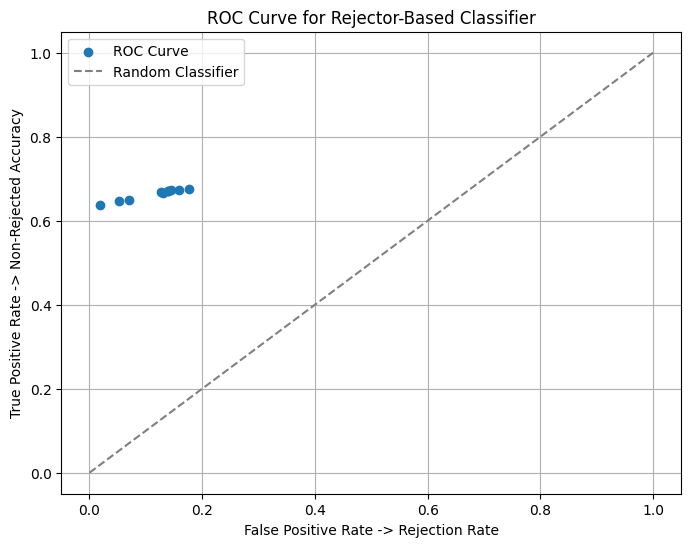

In [ ]:
# Initialize lists to store the fpr (rejection rate) and tpr (non-rejected accuracy)
fpr_values = []  # Rejection rate
tpr_values = []  # Non-rejected accuracy
epochs_list = []  # Epochs corresponding to each threshold (model)

for item in best_rejectors_indexes_by_thresholds:
    print('-----------------------')
    print(f"Eval for rejector model for threshold {item}:")

    # Get the rejector model and its predictions
    rejector_model = best_rejectors_indexes_by_thresholds[item]['rejector_model']
    rejector_preds = rejector_model.predict(test_X).argmax(axis=1)

    reject_class = test_Y.shape[1] - 1  # Index for rejected class
    rejected_indices = np.where(rejector_preds == reject_class)[0]
    num_rejected = len(rejected_indices)

    true_labels = test_Y.argmax(axis=1)  # True labels for test set

    if num_rejected == 0:
        print("No cases were rejected. No evaluation needed.")
    else:
        # Accuracy for non-rejected cases
        non_rejected_indices = np.where(rejector_preds != reject_class)[0]
        non_rejected_accuracy = np.sum(rejector_preds[non_rejected_indices] == true_labels[non_rejected_indices]) / len(non_rejected_indices)

        # Rejection rate is simply the percentage of rejected cases
        rejection_rate = num_rejected / len(test_X)

        # Store the fpr (rejection rate) and tpr (accuracy for non-rejected) for plotting
        fpr_values.append(rejection_rate)
        tpr_values.append(non_rejected_accuracy)
        epochs_list.append(item)  # Store the threshold (or epoch) as a reference

        # Print some stats for clarity
        print(f"Total rejected cases: {num_rejected}")
        print(f"Accuracy for non-rejected cases: {non_rejected_accuracy:.4f}")
        print(f"Rejection rate: {rejection_rate:.4f}")

    print('---------------------')

# Now that we have the rejection rates and accuracies, let's plot the ROC curve
plt.figure(figsize=(8, 6))

# Plot the ROC curve as a scatter plot
plt.scatter(fpr_values, tpr_values, marker='o', label="ROC Curve")

# Plot the random classifier (diagonal line)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Classifier")

# Labels and title
plt.xlabel("False Positive Rate -> Rejection Rate")
plt.ylabel("True Positive Rate -> Non-Rejected Accuracy")
plt.title("ROC Curve for Rejector-Based Classifier")

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [ ]:
sorted_indices = np.argsort(fpr_values)
fpr_sorted = np.array(fpr_values)[sorted_indices]
tpr_sorted = np.array(tpr_values)[sorted_indices]

# Compute AUC using the trapezoidal rule
auc_score = np.trapz(tpr_sorted, fpr_sorted)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.1035


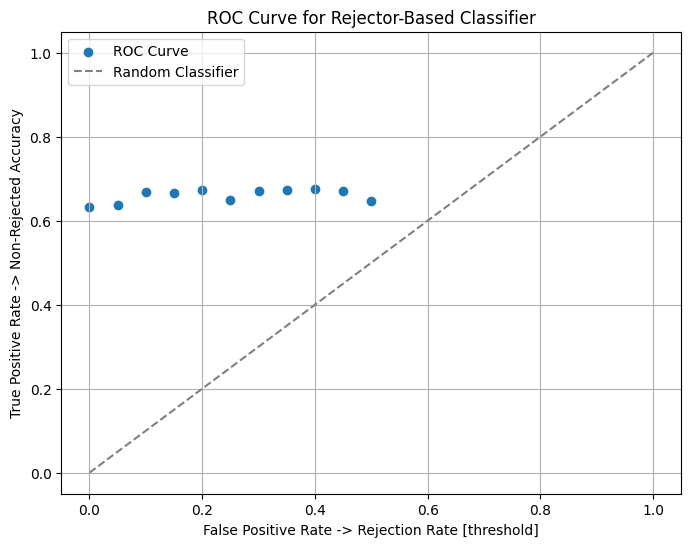

In [ ]:
# # Initialize lists to store the fpr (rejection rate) and tpr (non-rejected accuracy)
# fpr_values = []  # Rejection rate
# tpr_values = []  # Non-rejected accuracy
# epochs_list = []  # Epochs corresponding to each threshold (model)

# for item in best_rejectors_indexes_by_thresholds:
#     print('-----------------------')
#     print(f"Eval for rejector model for threshold {item}:")

#     # Get the rejector model and its predictions
#     rejector_model = best_rejectors_indexes_by_thresholds[item]['rejector_model']
#     rejector_preds = rejector_model.predict(test_X).argmax(axis=1)

#     reject_class = test_Y.shape[1] - 1  # Index for rejected class
#     rejected_indices = np.where(rejector_preds == reject_class)[0]
#     num_rejected = len(rejected_indices)

#     true_labels = test_Y.argmax(axis=1)  # True labels for test set

#     if num_rejected == 0:
#         print("No cases were rejected. No evaluation needed.")
#     else:
#         # Accuracy for non-rejected cases
#         non_rejected_indices = np.where(rejector_preds != reject_class)[0]
#         non_rejected_accuracy = np.sum(rejector_preds[non_rejected_indices] == true_labels[non_rejected_indices]) / len(non_rejected_indices)

#         # Rejection rate is simply the percentage of rejected cases
#         rejection_rate = num_rejected / len(test_X)

#         # Store the fpr (rejection rate) and tpr (accuracy for non-rejected) for plotting
#         # fpr_values.append(rejection_rate)
#         fpr_values.append(rejection_rate)
#         tpr_values.append(non_rejected_accuracy)
#         epochs_list.append(item)  # Store the threshold (or epoch) as a reference

#         # Print some stats for clarity
#         print(f"Total rejected cases: {num_rejected}")
#         print(f"Accuracy for non-rejected cases: {non_rejected_accuracy:.4f}")
#         print(f"Rejection rate [Thresholds]: {rejection_rate:.4f}")

#     print('---------------------')

# Now that we have the rejection rates and accuracies, let's plot the ROC curve
plt.figure(figsize=(8, 6))

# Plot the ROC curve as a scatter plot
plt.scatter(epochs_list + [0], tpr_values + [0.6323], marker='o', label="ROC Curve")

# Plot the random classifier (diagonal line)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Classifier")

# Labels and title
plt.xlabel("False Positive Rate -> Rejection Rate [threshold]")
plt.ylabel("True Positive Rate -> Non-Rejected Accuracy")
plt.title("ROC Curve for Rejector-Based Classifier")

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [ ]:
tpr_values

[0.6365475387727579,
 0.6681818181818182,
 0.6661596958174905,
 0.6720804331013148,
 0.6481876332622601,
 0.6697388632872504,
 0.6734854445318647,
 0.6755020080321286,
 0.6697388632872504,
 0.645949720670391]

In [ ]:
x = zip(tpr_values, fpr_values, epochs_list)
print("acc, rj rate, threshold")
for i in x:
  print(i)

acc, rj rate, threshold
(0.6365475387727579, 0.01917989417989418, 0.05)
(0.6681818181818182, 0.12698412698412698, 0.1)
(0.6661596958174905, 0.1302910052910053, 0.15)
(0.6720804331013148, 0.14484126984126985, 0.2)
(0.6481876332622601, 0.06944444444444445, 0.25)
(0.6697388632872504, 0.1388888888888889, 0.3)
(0.6734854445318647, 0.1593915343915344, 0.35)
(0.6755020080321286, 0.1765873015873016, 0.4)
(0.6697388632872504, 0.1388888888888889, 0.45)
(0.645949720670391, 0.05291005291005291, 0.5)


In [ ]:
0.6755020080321286 - 0.6323

0.04320200803212859

In [ ]:
0.6681818181818182 - 0.6323

0.03588181818181824

0.4 rejection thresholds that led to ~17 percent rejection rate for an improvment of 0.043 accuracy

0.1 rejection thresholds that led to ~13 percent rejection rate for an improvment of 0.0358 accuracy

48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 486ms/step


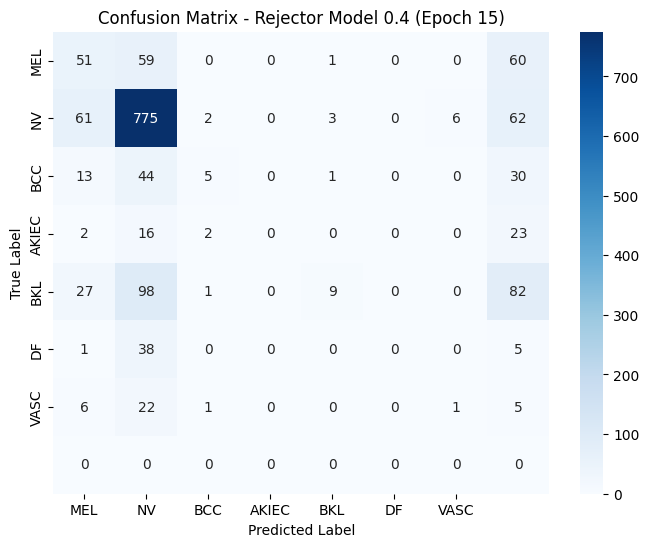

In [ ]:
rejector_model_04 = best_rejectors_indexes_by_thresholds[0.4]['rejector_model']

y_pred = rejector_model_04.predict(test_X)
y_pred_labels = y_pred.argmax(axis=1)  # Convert probabilities to class predictions
y_true_labels = test_Y.argmax(axis=1)  # Convert one-hot to class indices

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=Y_labels, yticklabels=Y_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Rejector Model 0.4 (Epoch 15)")
plt.show()


--

In [ ]:
for cur_threshold in thresholds:
  cur_metrics = eval_dict[cur_threshold]

  fpr = cur_metrics['rejection_rate']
  tpr = cur_metrics['test_acc']
  distances = np.sqrt(2 * np.array(fpr)**2 + (1 - np.array(tpr))**2)
  best_model_idx = np.argmin(distances)
  best_fpr = fpr[best_model_idx]
  best_tpr = tpr[best_model_idx]
  best_rj_rate = cur_metrics['rejection_rate'][best_model_idx]

  best_rejectors_indexes_by_thresholds_by_other_dist = [cur_threshold] = {"model_index": best_model_idx}

  print(f"Best Model Index: {best_model_idx}")
  print(f"Best FPR: {best_fpr:.4f}, Best TPR: {best_tpr:.4f}, Best Rejection Rate: {best_rj_rate:.4f}")

  print('----------------------------------------------')


Best Model Index: 13
Best FPR: 0.0192, Best TPR: 0.6365, Best Rejection Rate: 0.0192
----------------------------------------------
Best Model Index: 9
Best FPR: 0.0437, Best TPR: 0.6342, Best Rejection Rate: 0.0437
----------------------------------------------
Best Model Index: 12
Best FPR: 0.0377, Best TPR: 0.6371, Best Rejection Rate: 0.0377
----------------------------------------------
Best Model Index: 3
Best FPR: 0.1065, Best TPR: 0.6514, Best Rejection Rate: 0.1065
----------------------------------------------
Best Model Index: 16
Best FPR: 0.0694, Best TPR: 0.6482, Best Rejection Rate: 0.0694
----------------------------------------------
Best Model Index: 12
Best FPR: 0.0443, Best TPR: 0.6353, Best Rejection Rate: 0.0443
----------------------------------------------
Best Model Index: 17
Best FPR: 0.0873, Best TPR: 0.6449, Best Rejection Rate: 0.0873
----------------------------------------------
Best Model Index: 15
Best FPR: 0.1766, Best TPR: 0.6755, Best Rejection Rate: 

In [ ]:
model_name_base = f"./{base_project_folder_path}/final_models/model_rj_with_threshold_0.4"
model_name = model_name_base + f"_15epoch"
rejector_model = load_model_l(model_name)

././final_models/model_rj_with_threshold_0.4_15epoch
Loading existing model from .h5 format: ././final_models/model_rj_with_threshold_0.4_15epoch.h5


In [ ]:
test_preds = model.predict(test_X, batch_size=batch_size)
test_preds_classes = np.argmax(test_preds, axis=1)
true_classes = np.argmax(test_Y, axis=1)
reject_class = test_Y.shape[1] - 1

reject_mask = (test_preds_classes == reject_class)
rejection_rate = np.mean(reject_mask)

non_reject_mask = ~reject_mask
if np.any(non_reject_mask):
    valid_acc = np.mean(test_preds_classes[non_reject_mask] == true_classes[non_reject_mask])
else:
    valid_acc = 0

24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 629ms/step


In [ ]:
# import matplotlib.pyplot as plt

# # Extract all thresholds
# thresholds = list(eval_dict.keys())

# # Create subplots: 2 rows (FPR, TPR) x N columns (one per threshold)
# fig, axes = plt.subplots(2, len(thresholds), figsize=(5 * len(thresholds), 10))

# # Loop through each threshold and plot separately in its own column
# for i, threshold in enumerate(thresholds):
#     cur_metrics = eval_dict[threshold]
#     fpr = cur_metrics['rejection_rate']
#     tpr = cur_metrics['test_acc']
#     epochs = cur_metrics["epochs_list"]

#     # Plot FPR vs. Epochs (Rejection Rate)
#     axes[0, i].plot(epochs, fpr, marker='o', linestyle='-', label="Rejection Rate (FPR)", color="blue")
#     axes[0, i].set_title(f"Threshold {threshold} - Rejection Rate")
#     axes[0, i].set_xlabel("Epochs")
#     axes[0, i].set_ylabel("Rejection Rate (FPR)")
#     axes[0, i].legend()
#     axes[0, i].grid(True)

#     # Plot TPR vs. Epochs (Test Accuracy)
#     axes[1, i].plot(epochs, tpr, marker='o', linestyle='-', label="Test Accuracy (TPR)", color="orange")
#     axes[1, i].set_title(f"Threshold {threshold} - Test Accuracy")
#     axes[1, i].set_xlabel("Epochs")
#     axes[1, i].set_ylabel("Test Accuracy (TPR)")
#     axes[1, i].legend()
#     axes[1, i].grid(True)

# # Adjust layout for better readability
# plt.tight_layout()
# plt.show()
